In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)



In [4]:
df = pd.read_csv('files/bank-additional-clean-nonulls.csv', index_col=0)
df

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id,job,marital,education,default,housing,loan,contact,duration,campaign,previous,poutcome,empvarrate,conspriceidx,consconfidx,nremployed,y,date,latitude,longitude,contact_month,contact_year,age_cat,age,euribor3m,pdays
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,housemaid,married,basic 4y,No,No,No,telephone,261,1,0,nonexistent,1.1,93.994,-36.4,5191,no,2-agosto-2019,41.495,-71.233,agosto,2019.0,Adultos mayores,40.005436,4.857000,4.400000
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,services,married,high school,noviembre,No,No,telephone,149,1,0,nonexistent,1.1,93.994,-36.4,5191,no,14-septiembre-2016,34.601,-83.923,septiembre,2016.0,Mediana edad,57.000000,3.603174,4.800000
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,services,married,high school,No,Si,No,telephone,226,1,0,nonexistent,1.1,93.994,-36.4,5191,no,15-febrero-2019,34.939,-94.847,febrero,2019.0,Adultos jóvenes,37.000000,4.857000,7.000000
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,admin.,married,basic 6y,No,No,No,telephone,151,1,0,nonexistent,1.1,93.994,-36.4,5191,no,29-noviembre-2015,49.041,-70.308,noviembre,2015.0,Mediana edad,40.000000,3.595488,2.800000
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,services,married,high school,No,No,Si,telephone,307,1,0,nonexistent,1.1,93.994,-36.4,5191,no,29-enero-2017,38.033,-104.463,enero,2017.0,Mediana edad,56.000000,3.602722,5.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,68672,0,2,2014-03-08,22,4eed05de-2a98-4227-b488-32122009b638,admin.,married,university degree,No,No,No,cellular,618,2,0,nonexistent,1.4,93.444,-36.1,"5228,1",yes,13-octubre-2015,38.147,-105.582,octubre,2015.0,Adultos mayores,39.988040,3.595413,6.072418
42996,73578,0,2,2014-03-11,26,0f0aca88-4088-4fe2-905f-44fb675d9493,technician,married,professional course,No,Si,Si,cellular,42,7,0,nonexistent,-0.1,93.200,-42.0,"5195,8",no,17-marzo-2018,49.235,-112.201,marzo,2018.0,Adultos jóvenes,34.000000,3.592775,3.800000
42997,9816,2,2,2014-09-18,31,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,blue-collar,single,basic 6y,No,Si,No,cellular,391,2,0,nonexistent,1.4,93.918,-42.7,"5228,1",no,15-septiembre-2016,40.679,-120.015,septiembre,2016.0,Adultos mayores,39.988040,3.595413,6.072418
42998,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4,admin.,married,university degree,noviembre,No,No,cellular,674,3,0,nonexistent,1.4,93.918,-42.7,"5228,1",no,23-septiembre-2019,27.772,-117.518,septiembre,2019.0,Adultos mayores,40.006829,4.958000,4.400000


## Grafico de barras
- frecuencia (cantidad) de cada categoria de una variable categorica

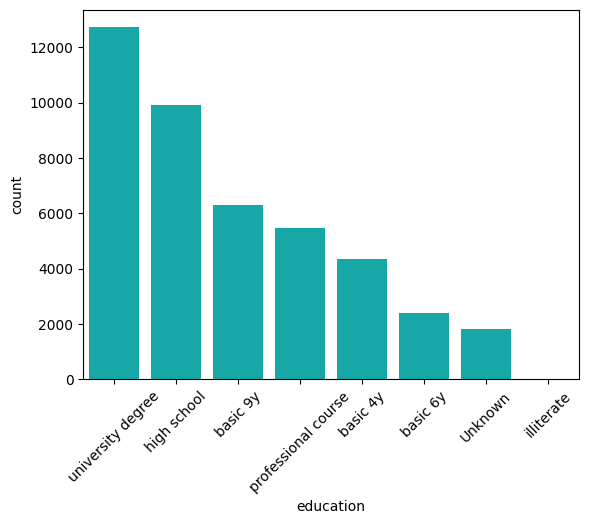

In [10]:
orden_educacion = df['education'].value_counts().index
sns.countplot(x='education', data=df, color='c', order=orden_educacion);
plt.xticks(rotation = 45); 

# Porcentajes o pprciones, tarta
- preparar los datos
- visualizamos

In [11]:
df_education = df.groupby('education')['id'].count().reset_index()
df_education

,education,id
0,Unknown,1807
1,basic 4y,4356
2,basic 6y,2386
3,basic 9y,6309
4,high school,9925
5,illiterate,18
6,professional course,5477
7,university degree,12722


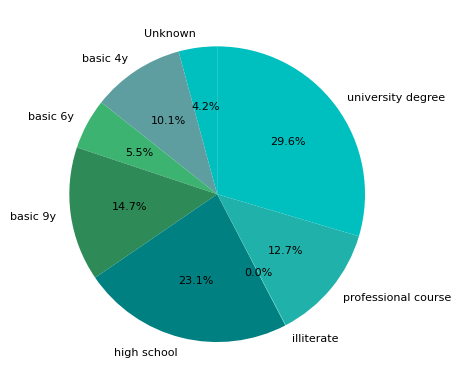

In [20]:
colores = ["c", "cadetblue", "mediumseagreen", "seagreen", "teal", "turquoise", "lightseagreen"]

plt.pie('id',
        data=df_education, 
        labels='education',
        autopct='%1.1f%%',
        colors=colores,
        textprops={'fontsize':8},
        startangle= 90);

## Countplot con hue 

/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_75464/1208249291.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:c'` for the same effect.

  sns.countplot(x='education', data=df, color='c', order=orden_educacion, hue='marital');


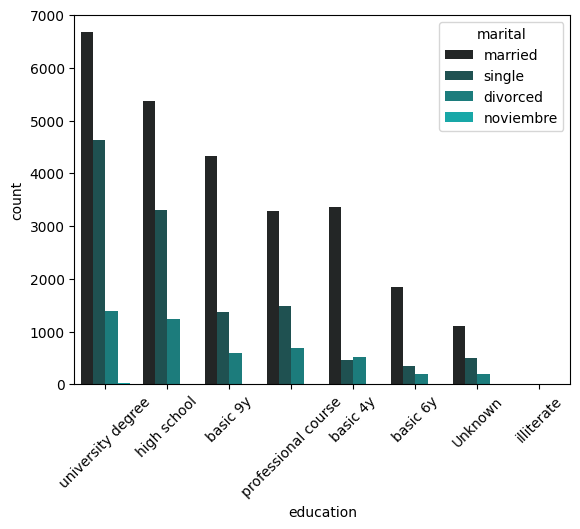

In [22]:
## relacion hay entre la eduación  y si contrató la campaña
orden_educacion = df['education'].value_counts().index
sns.countplot(x='education', data=df, color='c', order=orden_educacion, hue='marital');
plt.xticks(rotation = 45); 


# Tablas de contigencia

In [23]:
crosstab = pd.crosstab(df['education'], df['y'])
crosstab

y,no,yes
education,,
Unknown,1546,261
basic 4y,3908,448
basic 6y,2192,194
basic 9y,5816,493
high school,8849,1076
illiterate,14,4
professional course,4857,620
university degree,10974,1748


## Relacion de variables numericas y categoricas
- count plot
- barplot: grafico de barras 
- boxplot

/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_75464/1325242425.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'income', y= 'marital', data=df, palette='mako');


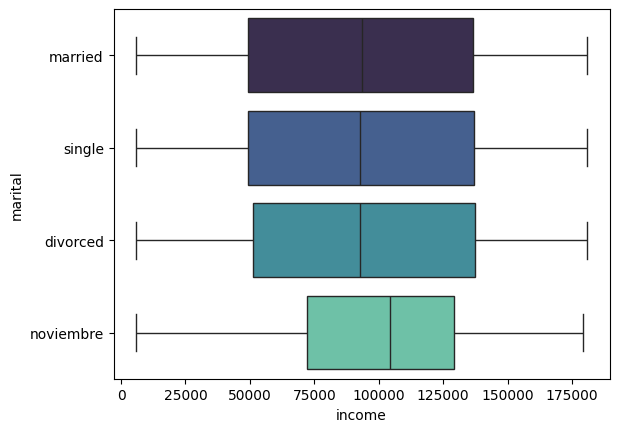

In [27]:
## relacion entre marital y income

sns.boxplot(x = 'income', y= 'marital', data=df, palette='mako'); 

/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_75464/318691206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='education', y='income', data=df, palette='magma')


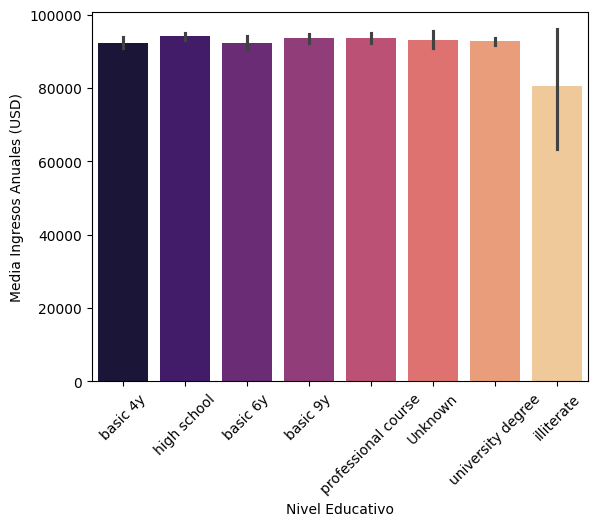

In [38]:
# sns.barplot muestra la media por defecto, las pequeñas líneas negras en la parte superior de las barras son los intervalos de confianza (el error estándar
# Guardamos el gráfico en la variable 'ax'
ax = sns.barplot(x='education', y='income', data=df, palette='magma')
# Cambiar nombres uno por uno
plt.xlabel("Nivel Educativo")
plt.ylabel("Media Ingresos Anuales (USD)")
# Tu rotación actual
plt.xticks(rotation=45)
plt.show()

In [35]:
# calcular la media por categoria 
# Calcular las medias exactas por nivel educativo
medias_educacion = df.groupby('education')['income'].mean().sort_values(ascending=False)

# Mostrar el resultado
print(medias_educacion)



education
high school            94141.961411
professional course    93669.489867
basic 9y               93563.364400
Unknown                93098.392916
university degree      92738.460148
basic 4y               92337.678375
basic 6y               92193.844929
illiterate             80480.388889
Name: income, dtype: float64


/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_75464/3893571446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'income', y= 'marital', data=df, palette='mako', ax= axes[0]);
/var/folders/cr/f3dqyy756z9ftxxsrmgtgjjh0000gn/T/ipykernel_75464/3893571446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='marital', y='income', data=df, palette='magma', ax= axes[1]);


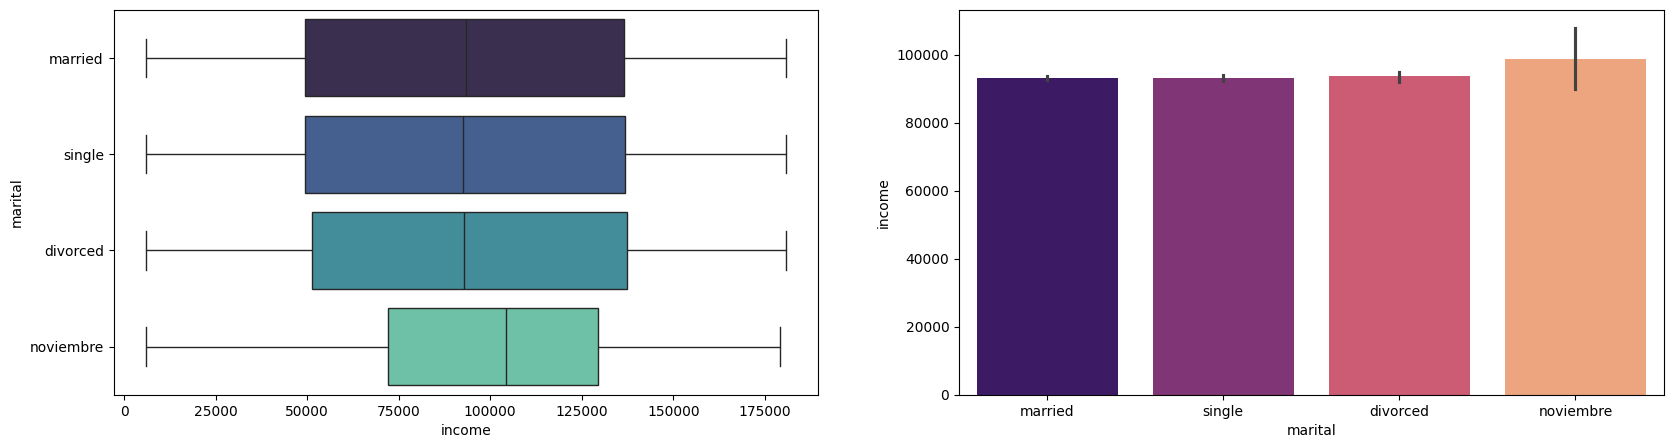

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (20,5))
sns.boxplot(x = 'income', y= 'marital', data=df, palette='mako', ax= axes[0]); 
sns.barplot(x='marital', y='income', data=df, palette='magma', ax= axes[1]); 
